In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
df = pd.read_csv("Ecommerce-Revenue-Analysis/dataset/ecommerce_sales.csv (2).csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 08:26,3.39,17850.0,United Kingdom


## **DATA** **UNDERSTANDING**

In [5]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (199999, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing Values:
InvoiceNo          0
StockCode          0
Description      790
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     58014
Country            0
dtype: int64

Statistical Summary:
            Quantity      UnitPrice     CustomerID
count  199999.000000  199999.000000  141985.000000
mean        9.280696       5.052210   15276.170765
std       240.493037      96.437302    1724.722230
min    -74215.000000       0.000000   12346.000000
25%         1.000000       1.250000   13824.000000
50%         3.000000       2.100000   15146.000000
75%        10.000000       4.210

## **Converting Date Column**

In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

## **Creating Revenue Column**

In [7]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## **Data Cleaning**

In [8]:
# remove returns
df_clean = df[df["Quantity"] > 0]

# remove rows with missing customer IDs
df_clean = df_clean.dropna(subset=["CustomerID"])

df_clean.shape

(138584, 9)

## **Top Products by Revenue**

In [9]:
top_products = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Revenue
Description,
MEDIUM CERAMIC TOP STORAGE JAR,77819.13
REGENCY CAKESTAND 3 TIER,74733.75
WHITE HANGING HEART T-LIGHT HOLDER,51440.80
POSTAGE,33173.70
JUMBO BAG RED RETROSPOT,30835.90
PARTY BUNTING,29218.15
ASSORTED COLOUR BIRD ORNAMENT,20801.50
CHILLI LIGHTS,18992.96
VINTAGE UNION JACK MEMOBOARD,17811.33


### **Visualization**

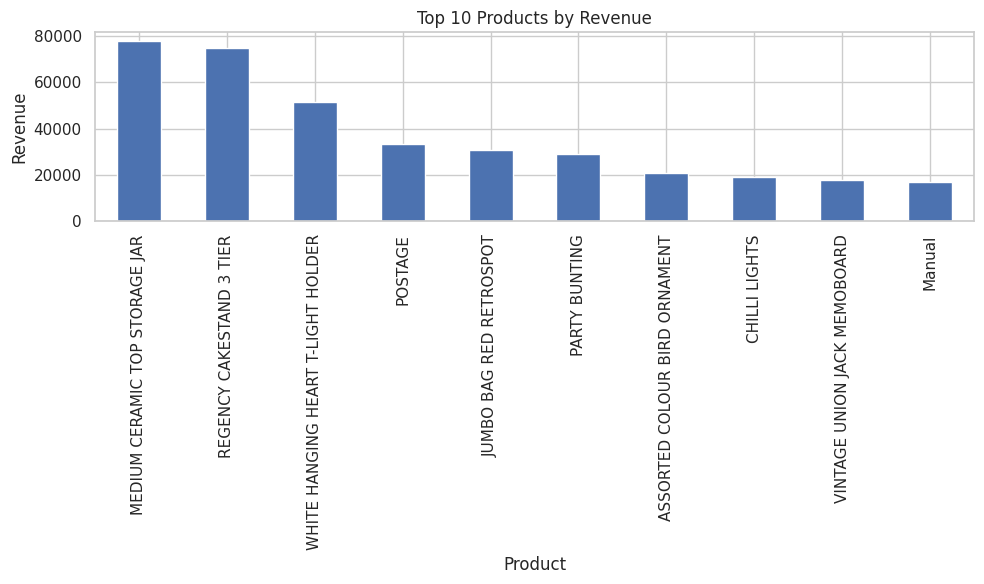

In [10]:
plt.figure(figsize=(10,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## **Revenue by Country**

In [11]:
revenue_country = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_country.head(10)

,Revenue
Country,
United Kingdom,2586265.491
Netherlands,102130.580
Germany,90475.610
EIRE,84569.850
France,69812.380
Australia,55907.890
Spain,23095.830
Japan,21434.730
Sweden,16041.780


### **Visualization**

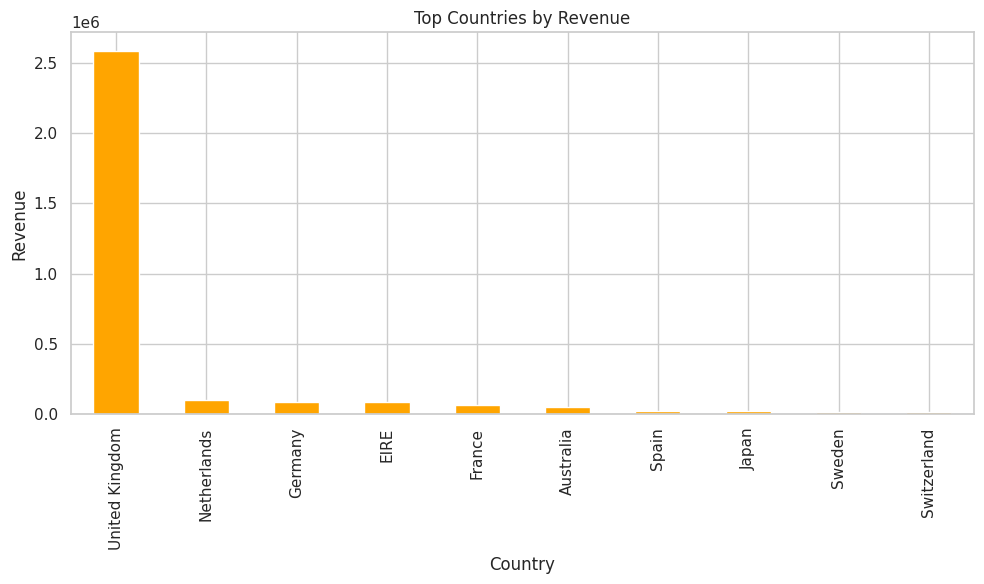

In [12]:
plt.figure(figsize=(10,6))

revenue_country.head(10).plot(kind="bar", color="orange")

plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## **Monthly Revenue Trend**

In [13]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    df_clean.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue.index = monthly_revenue.index.to_timestamp()

monthly_revenue

,Revenue
Month,
2010-12-01,572713.890
2011-01-01,569445.040
2011-02-01,447137.350
2011-03-01,595500.760
2011-04-01,469200.361
2011-05-01,510102.460


### **Visualization**

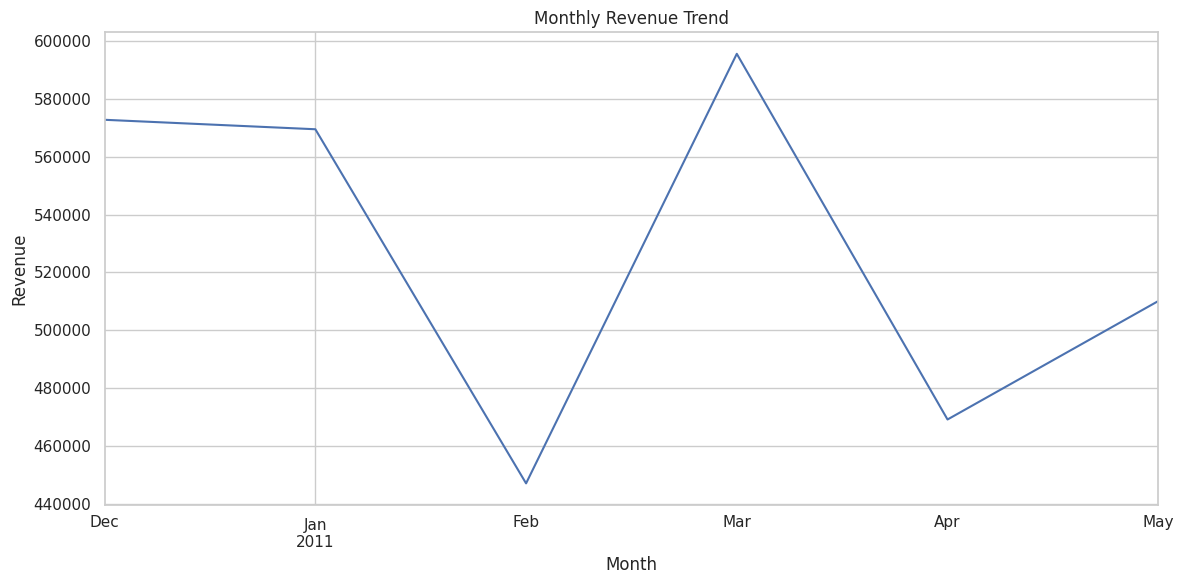

In [14]:
plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## **Customer Revenue Analysis**

In [15]:
customer_revenue = (
    df_clean.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

,Revenue
CustomerID,
14646.0,100340.24
12346.0,77183.60
18102.0,64642.11
12415.0,50883.90
15749.0,44534.30
14156.0,43907.23
17450.0,37734.58
14911.0,37297.99
17511.0,35750.40


## **Customer Spending Distribution**

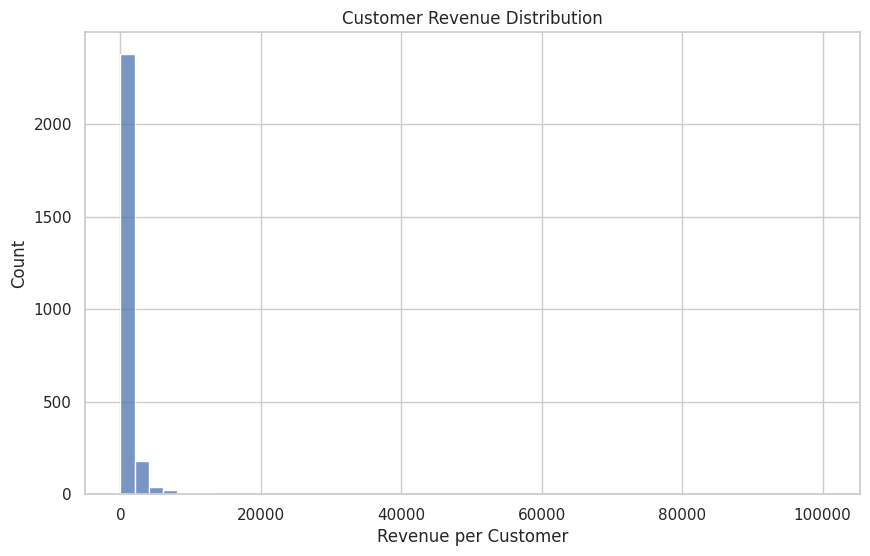

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(customer_revenue, bins=50)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue per Customer")

plt.show()

## **Top Customers**

In [17]:
top_customers = customer_revenue.head(10)

top_customers

,Revenue
CustomerID,
14646.0,100340.24
12346.0,77183.60
18102.0,64642.11
12415.0,50883.90
15749.0,44534.30
14156.0,43907.23
17450.0,37734.58
14911.0,37297.99
17511.0,35750.40


### **Visualization**

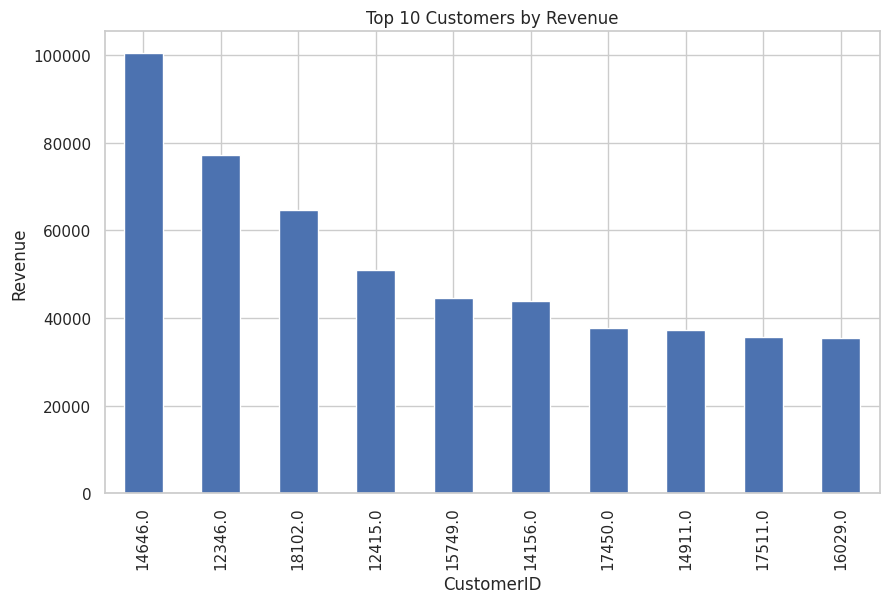

In [18]:
plt.figure(figsize=(10,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("CustomerID")
plt.ylabel("Revenue")

plt.show()

# **Key Business Insights**


Key Insights

• A small number of products generate a significant portion of total revenue.

• The United Kingdom dominates overall sales compared to other countries.

• Monthly sales trends reveal seasonal patterns in purchasing behaviour.

• A small segment of high-value customers contributes a large share of revenue.